# Day 38 (1/3) — The Perceptron Trick

**Goal:** learn a straight line that separates two classes by repeatedly nudging it toward misclassified points.
This is the starting point for logistic regression.

**In this notebook**
1. Build the perceptron trick from scratch (step function)
2. Turn learned weights into a line you can plot
3. Watch the line move during training
4. Compare it with scikit-learn's `LogisticRegression` and see the perceptron's weakness

> 📖 Theory: [`theory.md`](theory.md) §2–3

## Step 1 — Create a 2-class dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,
                           hypercube=False, class_sep=10)
print(X.shape, np.bincount(y))

(100, 2) [50 50]


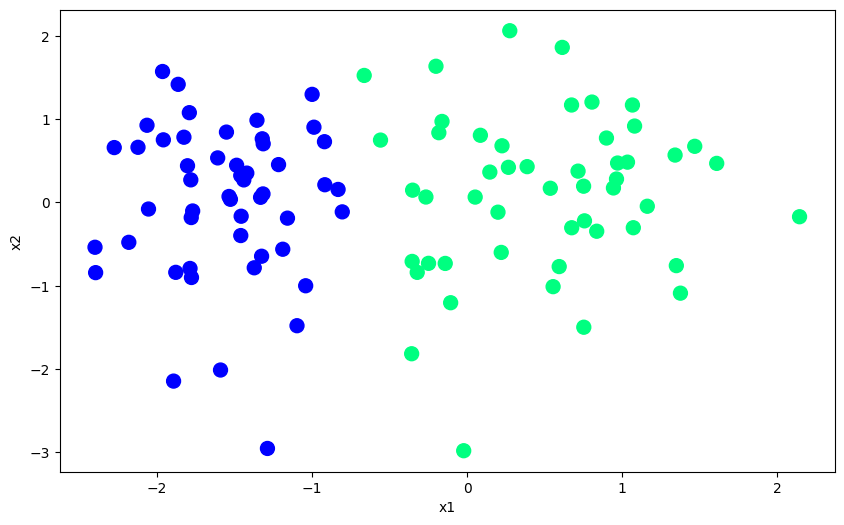

In [2]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

The classes are **linearly separable**: a straight line can split them perfectly.

## Step 2 — The perceptron trick

For a random point $(x_i, y_i)$:

$$\hat y_i = \text{step}(w \cdot x_i), \qquad w \leftarrow w + \eta\,(y_i - \hat y_i)\,x_i$$

- Correctly classified → $(y_i - \hat y_i) = 0$ → **no change**
- Misclassified → $\pm 1$ → the line moves toward fixing that point

`np.insert(X, 0, 1, axis=1)` adds a column of 1s so that `weights[0]` acts as the bias $b$ (theory §2, *bias trick*).

In [3]:
def step(z):
    return 1 if z > 0 else 0


def perceptron(X, y, lr=0.1, epochs=1000, seed=0):
    rng = np.random.default_rng(seed)
    X = np.insert(X, 0, 1, axis=1)          # bias column -> weights[0] is the intercept
    weights = np.ones(X.shape[1])

    for i in range(epochs):
        j = rng.integers(0, X.shape[0])     # pick one random point
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [4]:
intercept_, coef_ = perceptron(X, y)
print("coef_     :", coef_)
print("intercept_:", intercept_)

coef_     : [1.3423777  0.19109935]
intercept_: 1.0


## Step 3 — From weights to a line

The boundary is $w_1x_1 + w_2x_2 + b = 0$. Solving for $x_2$ gives slope $m = -w_1/w_2$ and intercept $c = -b/w_2$.

In [5]:
def boundary_line(intercept, coef, x_range=np.linspace(-3, 3, 100)):
    """Points on w1*x1 + w2*x2 + b = 0, i.e. x2 = -(w1/w2)*x1 - b/w2  (theory §2)."""
    m = -(coef[0] / coef[1])
    c = -(intercept / coef[1])
    return x_range, m * x_range + c

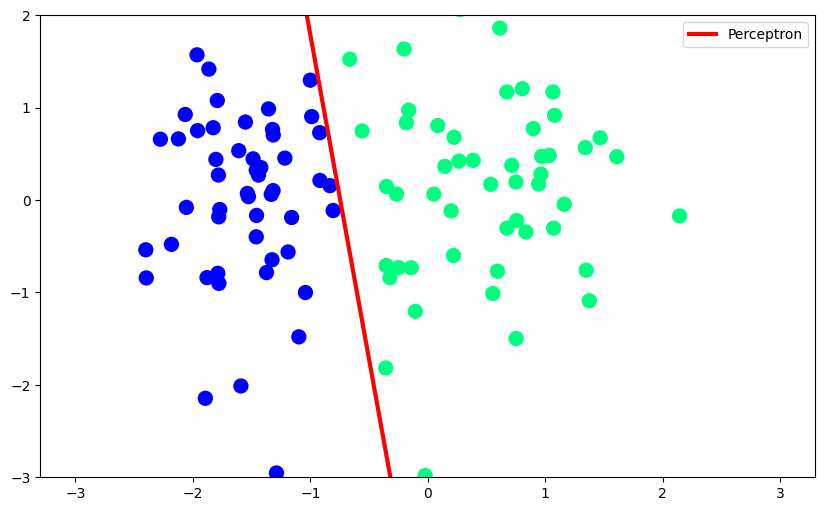

In [6]:
x_p, y_p = boundary_line(intercept_, coef_)

plt.figure(figsize=(10, 6))
plt.plot(x_p, y_p, color='red', linewidth=3, label='Perceptron')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.show()

## Step 4 — Watch the line learn

We record the line after each of the first 200 updates and animate it. Flat stretches are updates where the
chosen point was already correct, so $(y - \hat y) = 0$ and nothing changed.

In [7]:
def perceptron_history(X, y, lr=0.1, epochs=200, seed=0):
    rng = np.random.default_rng(seed)
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lines = []

    for i in range(epochs):
        j = rng.integers(0, X.shape[0])
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]
        lines.append((-(weights[1] / weights[2]), -(weights[0] / weights[2])))   # (slope, intercept)

    return lines

lines = perceptron_history(X, y)

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=60)
x_i = np.arange(-3, 3, 0.1)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
line, = ax.plot(x_i, lines[0][0] * x_i + lines[0][1], 'r-', linewidth=2)
ax.set_ylim(-3, 3)

def update(i):
    m, c = lines[i]
    line.set_ydata(m * x_i + c)
    ax.set_xlabel(f'update {i + 1}')
    return line,

anim = FuncAnimation(fig, update, frames=range(0, len(lines), 2), interval=100)   # every 2nd update keeps the file small
plt.close(fig)               # show only the animation, not a static copy
HTML(anim.to_jshtml())

## Step 5 — Compare with scikit-learn's Logistic Regression

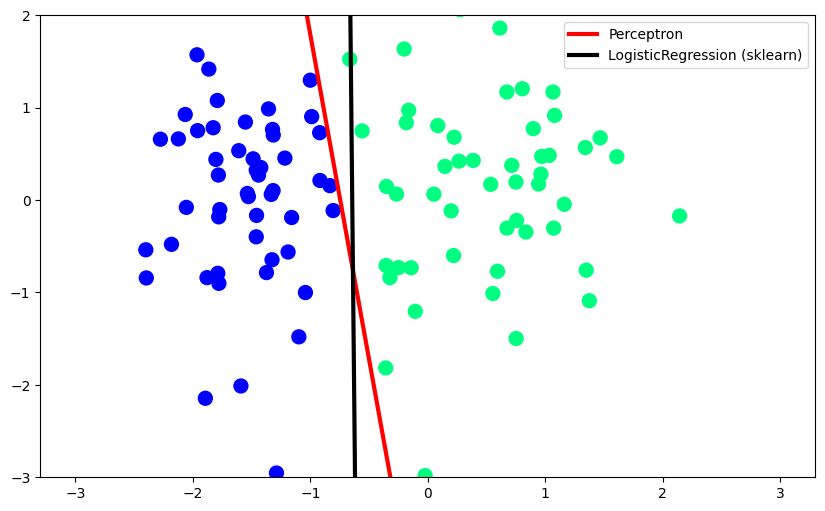

In [9]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression()
lor.fit(X, y)
x_l, y_l = boundary_line(lor.intercept_[0], lor.coef_[0])

plt.figure(figsize=(10, 6))
plt.plot(x_p, y_p, color='red', linewidth=3, label='Perceptron')
plt.plot(x_l, y_l, color='black', linewidth=3, label='LogisticRegression (sklearn)')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.show()

Let's measure each line: accuracy, and how close the **nearest point of each class** comes to it
(distance $= |w \cdot x + b| \,/\, \lVert w \rVert$; negative means that point is on the wrong side).

In [10]:
def describe_line(name, intercept, coef):
    z = intercept + X @ coef
    dist = z / np.linalg.norm(coef)                     # signed distance to the line
    acc = ((z > 0).astype(int) == y).mean()
    print(f"{name:<20} accuracy = {acc:.2f}   nearest class-0 point: {-dist[y == 0].max():6.3f}"
          f"   nearest class-1 point: {dist[y == 1].min():6.3f}")

describe_line("Perceptron", intercept_, coef_)
describe_line("LogisticRegression", lor.intercept_[0], lor.coef_[0])

Perceptron           accuracy = 1.00   nearest class-0 point:  0.065   nearest class-1 point:  0.127
LogisticRegression   accuracy = 0.99   nearest class-0 point:  0.163   nearest class-1 point: -0.009


**Observation.**
- The perceptron classifies **every** point correctly, but only just: its line passes within a few hundredths of a
  unit of the nearest points. As soon as every point is correct, all updates are 0 and training **stops at the first
  separating line it finds**, however close to the data it is. A slightly different new point could easily land on
  the wrong side.
- sklearn's line misclassifies one borderline point. By default it uses **L2 regularisation** (theory §8), which
  prefers a simpler model with smaller weights over fitting every training point perfectly.
- Neither model is "wrong", but only logistic regression is trained to optimise a meaningful objective (log-loss)
  and can tell you **how confident** it is. The perceptron gives neither.

### Key takeaways
- A linear classifier is fully described by $w$ and $b$; the boundary is $w \cdot x + b = 0$.
- Perceptron update: $w \leftarrow w + \eta (y - \hat y) x$; only misclassified points move the line.
- Weakness: it stops at any separator and gives no probabilities.

➡️ Next: **`02-perceptron-trick-sigmoid.ipynb`** fixes this by replacing the step function with a sigmoid.